In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import random
import os
from torch.utils.data import random_split

In [2]:
# 1. SEED SABİTLEME
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
# 2. TRANSFORMS
cifar_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [4]:
# 3. DATASET
class TaggedDataset(Dataset):
    def __init__(self, dataset, tag):
        self.dataset = dataset
        self.tag = tag
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        return img, label, self.tag

In [5]:
# Verileri Yükleme (Train ve Test ayrı ayrı indiriliyor)
mnist_train_raw = datasets.MNIST(root='./data', train=True, download=True, transform=mnist_transform)
mnist_test_raw  = datasets.MNIST(root='./data', train=False, download=True, transform=mnist_transform)

cifar_train_raw = datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)
cifar_test_raw  = datasets.CIFAR10(root='./data', train=False, download=True, transform=cifar_transform)

# Etiketleme
mnist_train_ds = TaggedDataset(mnist_train_raw, tag=0)
mnist_test_ds  = TaggedDataset(mnist_test_raw, tag=0)
cifar_train_ds = TaggedDataset(cifar_train_raw, tag=1)
cifar_test_ds  = TaggedDataset(cifar_test_raw, tag=1)

combined_train_dataset = ConcatDataset([mnist_train_ds, cifar_train_ds])

combined_test_dataset = ConcatDataset([mnist_test_ds, cifar_test_ds])

In [6]:
# Validation set
val_size = int(0.1 * len(combined_train_dataset))
train_size = len(combined_train_dataset) - val_size
train_ds, val_ds = random_split(combined_train_dataset, [train_size, val_size])

In [7]:
# Load
batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(combined_test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
class MixedMLP(nn.Module):
    def __init__(self, input_dim=28*28, output_dim=10):
        super().__init__()
        self.flat = nn.Flatten()
        
        # Katman 1
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256) # BatchNorm Eklendi
        self.relu1 = nn.ReLU()
        
        # Katman 2
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128) # BatchNorm Eklendi
        self.relu2 = nn.ReLU()
        
        self.fc3 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.flat(x)
        x = self.relu1(self.bn1(self.fc1(x))) # Sıralama: FC -> BN -> ReLU
        x = self.relu2(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return x

In [9]:
# Ayarlar
model = MixedMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # Learning rate
epochs = 15
patience = 5

valid_loss_min = np.inf
patience_counter = 0

In [10]:
# 5. EĞİTİM DÖNGÜSÜ
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels, tag in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Validation Phase
    model.eval()
    valid_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # Domain Analizi Değişkenleri
    correct_mnist = 0; total_mnist = 0
    correct_cifar = 0; total_cifar = 0
    
    with torch.no_grad():
        for data, target, tag in val_loader: # tqdm'i buradan kaldırdım çıktı kirlenmesin diye
            data, target = data.to(device), target.to(device)
            output = model(data)
            
            # Loss Hesabı (Early Stopping İçin Şart)
            loss_val = criterion(output, target)
            valid_loss += loss_val.item() * data.size(0)
            
            # Accuracy Hesabı
            pred = output.argmax(dim=1)
            correct_val += (pred == target).sum().item()
            total_val += target.size(0)
            
            # --- Domain Analizi ---
            mnist_mask = (tag == 0)
            cifar_mask = (tag == 1)
            
            if mnist_mask.sum() > 0:
                correct_mnist += pred[mnist_mask].eq(target[mnist_mask]).sum().item()
                total_mnist += mnist_mask.sum().item()
            if cifar_mask.sum() > 0:
                correct_cifar += pred[cifar_mask].eq(target[cifar_mask]).sum().item()
                total_cifar += cifar_mask.sum().item()

    # İstatistikler
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    
    val_loss_avg = valid_loss / len(val_loader.dataset)
    val_acc = 100. * correct_val / total_val
    
    acc_mnist = 100. * correct_mnist / total_mnist if total_mnist > 0 else 0
    acc_cifar = 100. * correct_cifar / total_cifar if total_cifar > 0 else 0

    print(f'\nEpoch [{epoch+1}/{epochs}]')
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_acc:.2f}%')
    print(f'   >>> [Domain Spec] MNIST: {acc_mnist:.2f}% | CIFAR: {acc_cifar:.2f}%')

    # Early Stopping
    if val_loss_avg <= valid_loss_min:
        print(f'Validation loss decreased ({valid_loss_min:.6f} --> {val_loss_avg:.6f}). Saving model...')
        torch.save(model.state_dict(), 'mixed_mlp_baseline.pth') # Modeli kaydetmeyi ekledim
        valid_loss_min = val_loss_avg
        patience_counter = 0
    else:
        patience_counter += 1
        print(f'EarlyStopping counter: {patience_counter} out of {patience}')
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1 Training: 100%|██████████| 774/774 [00:18<00:00, 41.71it/s]



Epoch [1/15]
Train Loss: 1.0308 | Train Acc: 64.60%
Val Loss:   0.9436 | Val Acc:   67.17%
   >>> [Domain Spec] MNIST: 94.56% | CIFAR: 35.84%
Validation loss decreased (inf --> 0.943637). Saving model...


Epoch 2 Training: 100%|██████████| 774/774 [00:18<00:00, 41.66it/s]



Epoch [2/15]
Train Loss: 0.8731 | Train Acc: 69.42%
Val Loss:   0.9047 | Val Acc:   68.68%
   >>> [Domain Spec] MNIST: 94.62% | CIFAR: 39.02%
Validation loss decreased (0.943637 --> 0.904695). Saving model...


Epoch 3 Training: 100%|██████████| 774/774 [00:18<00:00, 42.03it/s]


...


Epoch [13/15]
Train Loss: 0.6164 | Train Acc: 78.16%
Val Loss:   0.7864 | Val Acc:   73.80%
   >>> [Domain Spec] MNIST: 97.60% | CIFAR: 46.58%
EarlyStopping counter: 3 out of 5


Epoch 14 Training: 100%|██████████| 774/774 [00:17<00:00, 44.45it/s]



Epoch [14/15]
Train Loss: 0.6057 | Train Acc: 78.75%
Val Loss:   0.7827 | Val Acc:   73.23%
   >>> [Domain Spec] MNIST: 97.65% | CIFAR: 45.29%
EarlyStopping counter: 4 out of 5


Epoch 15 Training: 100%|██████████| 774/774 [00:17<00:00, 44.55it/s]



Epoch [15/15]
Train Loss: 0.5929 | Train Acc: 79.10%
Val Loss:   0.7761 | Val Acc:   74.27%
   >>> [Domain Spec] MNIST: 97.73% | CIFAR: 47.44%
EarlyStopping counter: 5 out of 5
Early stopping triggered.


In [11]:
# Modeli sıfırdan oluştur (Mimarisi eğitimdekiyle AYNEN aynı olmalı)
best_model = MixedMLP().to(device)

# Kaydedilen ağırlıkları yükle
best_model.load_state_dict(torch.load('mixed_mlp_baseline.pth'))
best_model.eval() # Değerlendirme moduna al (BatchNorm ve Dropout'u sabitler)

print("En iyi model başarıyla yüklendi!")

En iyi model başarıyla yüklendi!


In [12]:
# Verileri depolamak için listeler
all_preds = []
all_targets = []
all_tags = [] # Hangi verinin MNIST hangisinin CIFAR olduğunu tutmak için

test_correct_mnist = 0
test_total_mnist = 0
test_correct_cifar = 0
test_total_cifar = 0

with torch.no_grad():
    for data, target, tag in test_loader: # Test loader kullandığına emin ol
        data, target = data.to(device), target.to(device)
        output = best_model(data)
        
        # Tahminleri al
        pred = output.argmax(dim=1)
        
        # Listelere ekle (CPU'ya alıp numpy'a çeviriyoruz görselleştirme için)
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(target.cpu().numpy())
        all_tags.extend(tag.numpy())
        
        # Domain bazlı doğruluk hesabı
        mnist_mask = (tag == 0)
        cifar_mask = (tag == 1)
        
        if mnist_mask.sum() > 0:
            test_correct_mnist += pred[mnist_mask].eq(target[mnist_mask]).sum().item()
            test_total_mnist += mnist_mask.sum().item()
        
        if cifar_mask.sum() > 0:
            test_correct_cifar += pred[cifar_mask].eq(target[cifar_mask]).sum().item()
            test_total_cifar += cifar_mask.sum().item()

# Sonuçları Yazdır
acc_mnist = 100. * test_correct_mnist / test_total_mnist
acc_cifar = 100. * test_correct_cifar / test_total_cifar
overall_acc = 100. * (test_correct_mnist + test_correct_cifar) / (test_total_mnist + test_total_cifar)

print(f"--- TEST SONUÇLARI ---")
print(f"Genel Doğruluk: %{overall_acc:.2f}")
print(f"MNIST Doğruluk: %{acc_mnist:.2f}")
print(f"CIFAR Doğruluk: %{acc_cifar:.2f}")

--- TEST SONUÇLARI ---
Genel Doğruluk: %71.44
MNIST Doğruluk: %97.95
CIFAR Doğruluk: %44.93


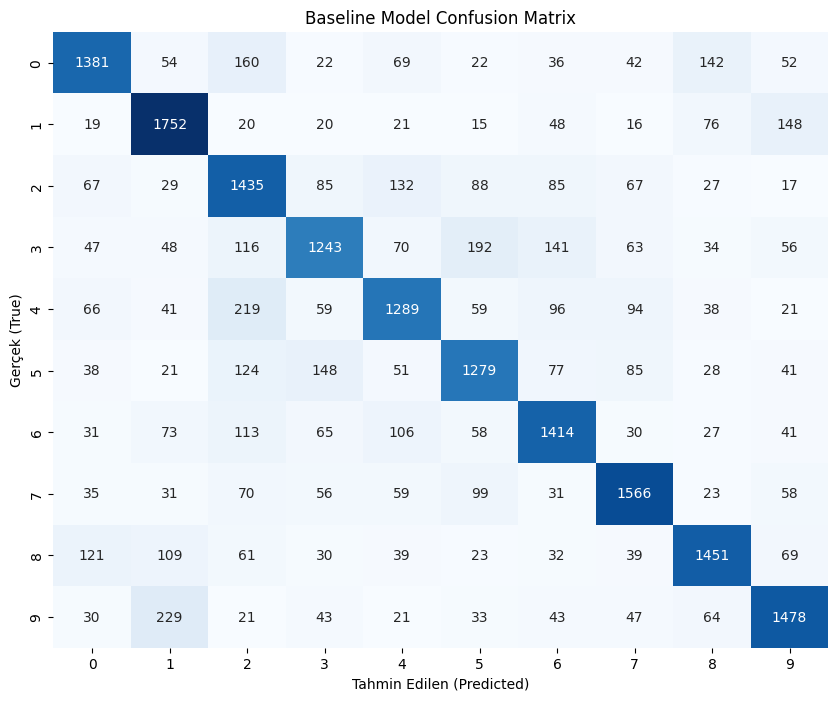

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix Hesapla
cm = confusion_matrix(all_targets, all_preds)

# Görselleştir
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Tahmin Edilen (Predicted)')
plt.ylabel('Gerçek (True)')
plt.title('Baseline Model Confusion Matrix')
plt.show()

Modelin Yanlış Bildiği Örnekler:


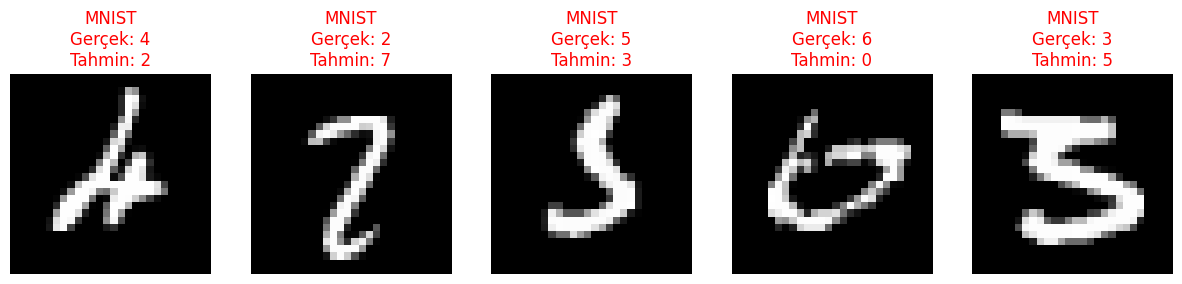

In [14]:
# Hatalı örnekleri bulalım
import numpy as np

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_tags = np.array(all_tags)
# Test loader'dan verileri tekrar çekmek yerine, yukarıdaki döngüde image'leri de saklayabilirdik 
# ama bellek dolmasın diye, test setinden rastgele hatalı örnek bulalım:

def show_failures(model, loader, device, num_images=5):
    model.eval()
    images_shown = 0
    
    plt.figure(figsize=(15, 3))
    
    with torch.no_grad():
        for data, target, tag in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            
            # Hatalı olanları bul (pred != target)
            wrong_indices = (pred != target).nonzero(as_tuple=True)[0]
            
            for idx in wrong_indices:
                if images_shown >= num_images:
                    break
                
                img = data[idx].cpu().squeeze() # (1, 28, 28) -> (28, 28)
                true_label = target[idx].item()
                pred_label = pred[idx].item()
                domain = "MNIST" if tag[idx].item() == 0 else "CIFAR"
                
                # Resmi çiz
                plt.subplot(1, num_images, images_shown + 1)
                plt.imshow(img, cmap='gray')
                plt.title(f"{domain}\nGerçek: {true_label}\nTahmin: {pred_label}", color='red')
                plt.axis('off')
                
                images_shown += 1
            
            if images_shown >= num_images:
                break
    plt.show()

print("Modelin Yanlış Bildiği Örnekler:")
show_failures(best_model, test_loader, device)

Test analizi yapılıyor (Lütfen bekleyin)...

     DETAYLI TEST SONUÇLARI
Genel Doğruluk      : %71.44
MNIST Doğruluğu     : %97.95
CIFAR-10 Doğruluğu  : %44.93


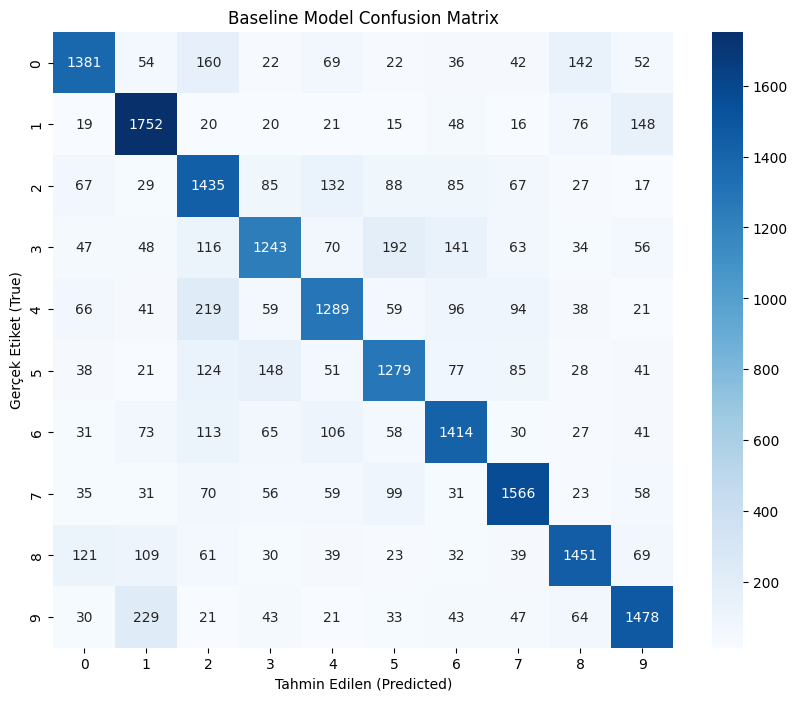

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Test Hazırlığı
# Eğer 'best_model' tanımlı değilse, eğitimden çıkan 'model'i kullanabiliriz
if 'best_model' not in globals():
    best_model = model 

best_model.eval()

all_preds = []
all_targets = []
all_tags = []

correct_mnist = 0; total_mnist = 0
correct_cifar = 0; total_cifar = 0

print("Test analizi yapılıyor (Lütfen bekleyin)...")

# 2. Veri Toplama Döngüsü
with torch.no_grad():
    for data, target, tag in test_loader:
        data, target, tag = data.to(device), target.to(device), tag.to(device)
        
        output = best_model(data)
        pred = output.argmax(dim=1)
        
        # Analiz için listelere ekle
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(target.cpu().numpy())
        all_tags.extend(tag.cpu().numpy())
        
        # Ayrıştırılmış doğruluk hesabı
        mnist_mask = (tag == 0)
        cifar_mask = (tag == 1)
        
        if mnist_mask.sum() > 0:
            correct_mnist += pred[mnist_mask].eq(target[mnist_mask]).sum().item()
            total_mnist += mnist_mask.sum().item()
        if cifar_mask.sum() > 0:
            correct_cifar += pred[cifar_mask].eq(target[cifar_mask]).sum().item()
            total_cifar += cifar_mask.sum().item()

# 3. Sonuçları Hesapla ve Yazdır
acc_mnist = 100. * correct_mnist / total_mnist if total_mnist > 0 else 0
acc_cifar = 100. * correct_cifar / total_cifar if total_cifar > 0 else 0
overall_acc = 100. * (correct_mnist + correct_cifar) / (total_mnist + total_cifar)

print("\n" + "="*30)
print("     DETAYLI TEST SONUÇLARI")
print("="*30)
print(f"Genel Doğruluk      : %{overall_acc:.2f}")
print(f"MNIST Doğruluğu     : %{acc_mnist:.2f}")
print(f"CIFAR-10 Doğruluğu  : %{acc_cifar:.2f}")
print("="*30)

# 4. Confusion Matrix Çizdir
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Baseline Model Confusion Matrix')
plt.xlabel('Tahmin Edilen (Predicted)')
plt.ylabel('Gerçek Etiket (True)')
plt.show()